# QUALIPHIDE Inference Pipeline — Tutorial

This notebook walks through each stage of the QUALIPHIDE hidden photon dark matter
inference pipeline step by step.

**Important:** For demonstration purposes we use a very small number of toys (`n_toy=10`).
A real analysis requires thousands of toys — see the YAML configs in `configs/` for
production settings.

Before running, install the package:
```bash
pip install -e ..
```

In [1]:
import os, sys
# Run from the repo root so config/output paths resolve correctly
os.chdir(os.path.join(os.path.dirname(os.path.abspath(".")), ""))
# If running from notebooks/, go up one level
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import numpy as np
import matplotlib.pyplot as plt

from qualiphide.config import load_config, load_derived_data

## 1. Preprocessing

`load_config()` reads the YAML file and runs three preprocessing steps:

1. **`interpolate_efficiency()`** — interpolates detector efficiency curves onto a uniform energy grid
2. **`process_background_spectra()`** — builds background PDFs split into below/above regions
3. **`fit_background_rates()`** — fits skew-normal distributions to per-channel rates and convolves for 4-KID

These write intermediate CSVs and plots into the output directory.

n_toy: 2501
m_test: [0.013    0.032374 0.080623 0.200777 0.5     ]
chi_true (first 5): [0.000e+00 1.000e-13 2.154e-13 4.642e-13 1.000e-12]
Physics: N_KID=4, runtime=78048s
Cutoffs: EnergyCutoffs(cutoff=0.013, split=0.07, maximum=0.5, split_mu_b=0.04)


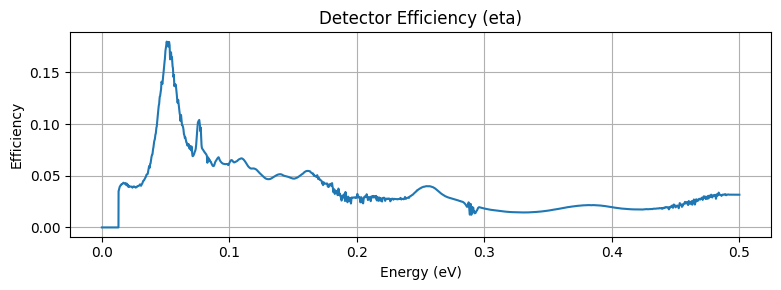

In [2]:
%matplotlib inline
# Load config — this also runs preprocessing
cfg = load_config("config")

print(f"n_toy: {cfg.n_toy}")
print(f"m_test: {cfg.m_test}")
print(f"chi_true (first 5): {cfg.chi_true[:5]}")
print(f"Physics: N_KID={cfg.physics.N_KID}, runtime={cfg.physics.runtime:.0f}s")
print(f"Cutoffs: {cfg.cutoffs}")

# Plot the efficiency curve from preprocessing output
eta_data = np.loadtxt(f"{cfg.name}/eta_full.csv", delimiter=",", skiprows=1)
plt.figure(figsize=(8, 3))
plt.plot(eta_data[:, 0], eta_data[:, 1])
plt.xlabel("Energy (eV)")
plt.ylabel("Efficiency")
plt.title("Detector Efficiency (eta)")
plt.grid(True)
plt.tight_layout()
plt.show()

## 2. Loading Derived Data for a Specific Mass

`load_derived_data()` loads the preprocessed CSVs and the resolution model,
then interpolates everything to a specific test mass. It returns:

- **`InterpolationData`** — energy grid, efficiency, background PDFs, mu_b distributions
- **`ResolutionData`** — median resolution and asymmetric 1-sigma deviations

In [3]:
# Pick the first mass point for demonstration
m = cfg.m_test[0]
print(f"Test mass: {m} eV")

interp_data, res_data = load_derived_data(cfg.name, m)

print(f"\nInterpolated fields:")
print(f"  energies shape: {interp_data.energies.shape}")
print(f"  eta_used (efficiency at m={m}): {interp_data.eta_used:.4f}")
print(f"  eta_a shape: {interp_data.eta_a.shape}")
print(f"  f_b_below shape: {interp_data.f_b_below.shape}")
print(f"  f_b_above shape: {interp_data.f_b_above.shape}")

print(f"\nResolution at {m} eV:")
print(f"  median: {res_data.median:.6f} eV")
print(f"  delta_low: {res_data.delta_low:.6f} eV")
print(f"  delta_up: {res_data.delta_up:.6f} eV")

Test mass: 0.013 eV

Interpolated fields:
  energies shape: (50001,)
  eta_used (efficiency at m=0.013): 0.0351
  eta_a shape: (50001,)
  f_b_below shape: (50001,)
  f_b_above shape: (50001,)

Resolution at 0.013 eV:
  median: 0.005845 eV
  delta_low: 0.000486 eV
  delta_up: 0.000933 eV


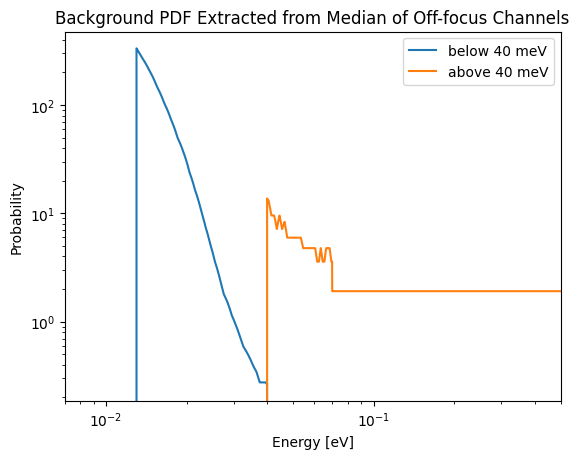

In [4]:
plt.plot(interp_data.energies, interp_data.f_b_below, label="below 40 meV")
plt.plot(interp_data.energies, interp_data.f_b_above, label="above 40 meV")
plt.xscale("log")
plt.yscale("log")
plt.xlim(0.007, 0.500)
plt.xlabel("Energy [eV]")
plt.ylabel("Probability")
plt.title("Background PDF Extracted from Median of Off-focus Channels")
plt.legend()

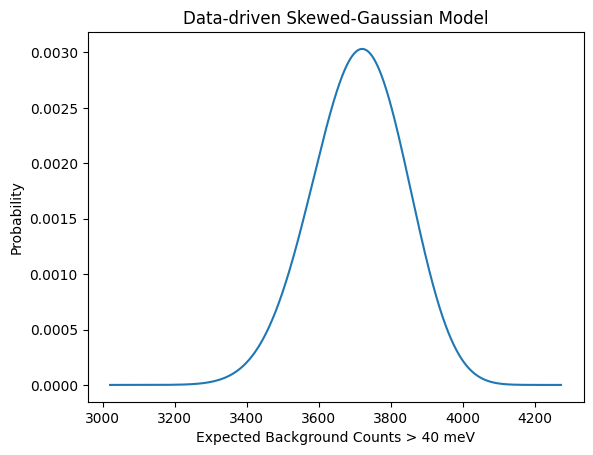

In [5]:
plt.plot(interp_data.mu_b_data_above[0], interp_data.mu_b_data_above[1])
plt.xlabel("Expected Background Counts > 40 meV")
plt.ylabel("Probability")
plt.title("Data-driven Skewed-Gaussian Model")
plt.show()


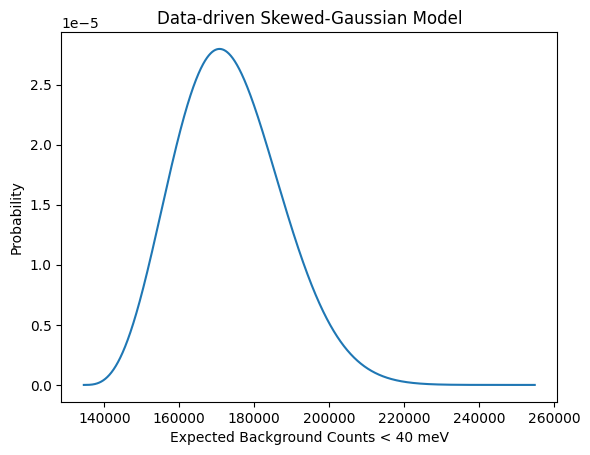

In [6]:
plt.plot(interp_data.mu_b_data_below[0], interp_data.mu_b_data_below[1])
plt.xlabel("Expected Background Counts < 40 meV")
plt.ylabel("Probability")
plt.title("Data-driven Skewed-Gaussian Model")
plt.show()


## 3. ToyMC Generation

`generate_toymc()` creates pseudo-experiments by sampling:
- Nuisance parameters: detector efficiency `eta`, background counts `mu_b`, resolution `r`
- Signal events from the signal PDF (Gaussian at mass m, smeared by resolution)
- Background events from randomly selected channel combinations

Each toy is a `ToyData` named tuple containing observed energies, sampled nuisance
parameters, event counts, and the indices of the 4 background channels used.

`build_background_pdfs()` reconstructs the below/above background PDFs for a given
set of channel indices — useful for inspecting what a specific toy "saw".

Using chi = 5e-11
Generated 100 signal toys
First toy: 203392 total events (33893 signal, 169499 bkg), eta=0.0363, mu_b_below=165517.8, mu_b_above=3829.0


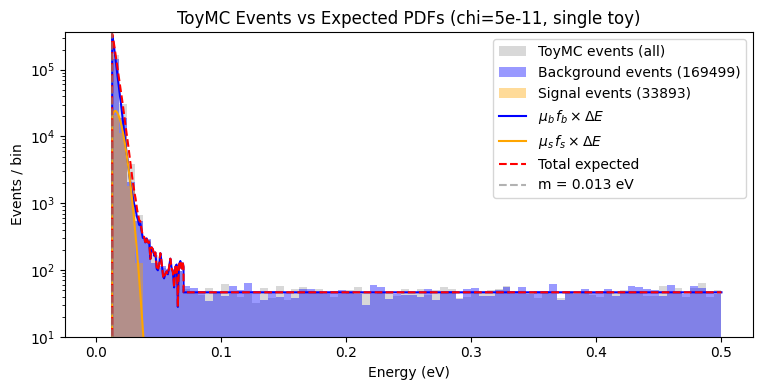

In [7]:
from qualiphide.toymc import generate_toymc, load_channel_data, _process_channels, build_background_pdfs
from qualiphide.signal import generate_signal_pdf
from scipy.integrate import cumulative_trapezoid

# Generate 100 signal toys with a large chi for visible signal
n_toy_demo = 100
c_demo = 5e-11  # large chi for visible signal
print(f"Using chi = {c_demo}")

signal_toys = generate_toymc(
    n_toy_demo, c_demo, m, cfg.physics,
    interp_data, res_data, cfg.cutoffs,
)

print(f"Generated {len(signal_toys)} signal toys")
toy = signal_toys[0]
print(f"First toy: {len(toy.observed_energies)} total events "
      f"({toy.n_signal} signal, {toy.n_bkg_below + toy.n_bkg_above} bkg), "
      f"eta={toy.eta:.4f}, "
      f"mu_b_below={toy.mu_b_below:.1f}, "
      f"mu_b_above={toy.mu_b_above:.1f}")

# --- Reconstruct expected PDFs for this toy ---
channel_data = load_channel_data()
channels = _process_channels(channel_data, interp_data.energies)

energies, f_b_below, f_b_above = build_background_pdfs(
    toy.bkg_channel_indices, channels, interp_data.energies,
    cfg.cutoffs.cutoff, cfg.cutoffs.split, cfg.cutoffs.maximum,
    cfg.cutoffs.split_mu_b,
)

resolution = max(1e-6,
    res_data.median + toy.r * (res_data.delta_low if toy.r < 0 else res_data.delta_up))
f_s = generate_signal_pdf(
    m, cfg.cutoffs.cutoff, cfg.cutoffs.split, cfg.cutoffs.maximum,
    resolution, energies, interp_data.eta_a,
)

N_gamma_det = cfg.physics.runtime * (c_demo / cfg.physics.chi_N_m_factor) ** 2 * (1 / m)
mu_s = toy.eta * N_gamma_det / cfg.physics.N_KID

expected_bkg = toy.mu_b_below * f_b_below + toy.mu_b_above * f_b_above
expected_sig = mu_s * f_s

# Re-sample signal and background events separately for visualization
# (observed_energies is sorted, so the original split is lost)
cdf_s = cumulative_trapezoid(f_s, x=energies, initial=0)
cdf_b_below = cumulative_trapezoid(f_b_below, x=energies, initial=0)
cdf_b_above = cumulative_trapezoid(f_b_above, x=energies, initial=0)

sig_events = np.interp(np.random.random(toy.n_signal), cdf_s, energies)
bkg_events = np.concatenate([
    np.interp(np.random.random(toy.n_bkg_below), cdf_b_below, energies),
    np.interp(np.random.random(toy.n_bkg_above), cdf_b_above, energies),
])

plt.figure(figsize=(8, 4))
n_bins = 80
bin_edges = np.linspace(energies[0], energies[-1], n_bins + 1)
bin_width = bin_edges[1] - bin_edges[0]

plt.hist(toy.observed_energies, bins=bin_edges, alpha=0.3, color="gray",
         label="ToyMC events (all)")
plt.hist(bkg_events, bins=bin_edges, alpha=0.4, color="blue",
         label=f"Background events ({toy.n_bkg_below + toy.n_bkg_above})")
plt.hist(sig_events, bins=bin_edges, alpha=0.4, color="orange",
         label=f"Signal events ({toy.n_signal})")

plt.plot(energies, expected_bkg * bin_width, color="blue", linewidth=1.5,
         label=r"$\mu_b \, f_b \times \Delta E$")
plt.plot(energies, expected_sig * bin_width, color="orange", linewidth=1.5,
         label=r"$\mu_s \, f_s \times \Delta E$")
plt.plot(energies, (expected_bkg + expected_sig) * bin_width, color="red",
         linewidth=1.5, linestyle="--", label="Total expected")
plt.axvline(m, color="gray", linestyle="--", alpha=0.6, label=f"m = {m} eV")
plt.xlabel("Energy (eV)")
plt.ylabel("Events / bin")
plt.title(f"ToyMC Events vs Expected PDFs (chi={c_demo}, single toy)")
plt.legend()
plt.tight_layout()
plt.ylim(10)
plt.yscale("log")
plt.show()

## 4. Fit Results and Profile Likelihood Ratio Test

The test statistic is `q = 2 * (NLL_constrained - NLL_unconstrained)`:

- **Unconstrained** (`minimize_unconstrained`): all parameters free — finds global best fit
- **Constrained** (`minimize_constrained`): `N_gamma_det` fixed to the hypothesised chi — only nuisance parameters vary

`compute_fit_results()` runs both fits for every toy and saves per-toy results including
q values, best-fit parameters from both fits, and the true nuisance parameter values.
The **discovery threshold** `q_disc` is the 99.865th percentile of the null q distribution.

In [8]:
# Generate null toys (chi=0) needed for fit results and sensitivity
null_toys = generate_toymc(
    n_toy_demo, 0.0, m, cfg.physics,
    interp_data, res_data, cfg.cutoffs,
)
print(f"Generated {len(null_toys)} null toys")

Generated 100 null toys


In [9]:
from qualiphide.minimization import compute_fit_results

# Compute fit results for null hypothesis (chi=0)
# This runs the full minimisation for each toy — may take a minute even with 10 toys
q_disc, nll_max_null = compute_fit_results(
    null_toys, 0.0, m, cfg.physics,
    cfg.name, interp_data, res_data, cfg.cutoffs,
)

print(f"\nDiscovery threshold q_disc (99.865th percentile): {q_disc:.4f}")


Discovery threshold q_disc (99.865th percentile): 251.2558


## 5. Three-Sigma Discovery Probability

For a given signal chi, `compute_discovery_probability()`:
1. Generates signal ToyMC at that chi
2. Computes q for each signal toy
3. Counts the fraction with q > q_disc (the null threshold)

This fraction is the **discovery probability** — the chance of a >3-sigma detection
at that (mass, chi) point.

In [10]:
from qualiphide.discovery import compute_discovery_probability

# Pick a nonzero chi value for the signal hypothesis
c_signal = cfg.chi_true[1]  # first nonzero chi
print(f"Signal chi: {c_signal}")

# Generate signal toys
signal_toys = generate_toymc(
    n_toy_demo, c_signal, m, cfg.physics,
    interp_data, res_data, cfg.cutoffs,
)

# Compute fit results for the signal toys (needed for nll_max)
_, nll_max_signal = compute_fit_results(
    signal_toys, c_signal, m, cfg.physics,
    cfg.name, interp_data, res_data, cfg.cutoffs,
)

# Compute discovery probability
prob = compute_discovery_probability(
    signal_toys, n_toy_demo, c_signal, m,
    cfg.chi_true[1:], cfg.physics, cfg.name,
    q_disc, interp_data, res_data, cfg.cutoffs, nll_max_signal,
)
print(f"\nDiscovery probability at chi={c_signal}: {prob}")

Signal chi: 1e-13

Discovery probability at chi=1e-13: 1.0


## 6. Sensitivity Scan

`compute_sensitivity()` uses per-toy bisection to find upper limits on chi:
1. Given a `(chi_lo, chi_hi)` bracket, each toy independently bisects to find where the PLR curve crosses the threshold
2. Collects upper limits across all toys → Brazil-band percentiles

`plot_sensitivity_band()` then plots the familiar green/yellow exclusion band.

In [11]:
%matplotlib inline
from qualiphide.sensitivity import compute_sensitivity
from qualiphide.minimization import plot_fit_results

# Plot fit results first (needed for q0 threshold file)
plot_fit_results(m, cfg.chi_true[:3], cfg.name)

# Define bisection bracket for sensitivity scan
chi_lo = float(cfg.chi_true[1])
chi_hi = float(cfg.chi_true[min(3, len(cfg.chi_true) - 1)])
chi_bounds = (chi_lo / 2, chi_hi * 2)

# Run the sensitivity scan (uses null toys with per-toy bisection)
print(f"Running sensitivity bisection with bracket {chi_bounds}...")
compute_sensitivity(
    null_toys, n_toy_demo, m, cfg.physics, cfg.name,
    chi_bounds, interp_data, res_data, cfg.cutoffs, nll_max_null,
)
print("Done!")

Running sensitivity bisection with bracket (5e-14, 9.284e-13)...


Done!


## Summary

This tutorial walked through the full QUALIPHIDE inference pipeline:

1. **Config & Preprocessing** — `load_config()` reads YAML and runs efficiency/background/rate preprocessing
2. **Derived Data** — `load_derived_data()` interpolates to a specific mass point
3. **ToyMC** — `generate_toymc()` creates pseudo-experiments with sampled nuisance parameters
4. **Fit Results** — `compute_fit_results()` computes the PLR test statistic and saves per-toy fit results
5. **Discovery** — `compute_discovery_probability()` evaluates the 3-sigma detection probability
6. **Sensitivity** — `compute_sensitivity()` scans chi to find upper limits (Brazil band)

For a full production run across all masses, use the CLI:
```bash
qualiphide config
```

See the YAML configs in `configs/` for all tunable parameters.